In [201]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**LIBRERIAS**

In [202]:
# Manipulación de datos
import pandas as pd
import numpy as np
# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
# Análisis y preprocesamiento
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report
# Balanceo de datos
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
# Codificadores avanzados
!pip install category_encoders
import category_encoders as ce
# Análisis de correlación y ranking
from scipy.stats import pearsonr
from sklearn.feature_selection import mutual_info_classif
# Warnings (para mantener limpio el output)
import warnings
warnings.filterwarnings('ignore')

**1. DESCRIPCION GENERAL DEL DATASET**





In [203]:
#Cargar el dataset
ruta = '/content/drive/MyDrive/PC2/DATOS INICIALES/application_train.csv'
df = pd.read_csv(ruta)

#Mostrar las primeras filas
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


Se cargó el archivo application_train.csv, correspondiente al dataset Home Credit Default Risk. Este archivo contiene la información principal de los clientes que solicitaron un crédito, junto con la variable objetivo TARGET, que indica si el cliente presentó o no dificultades de pago.

In [204]:
#Número de filas y columnas
filas, columnas = df.shape

print(f"Número de filas: {filas}")
print(f"Número de columnas: {columnas}")

Número de filas: 307511
Número de columnas: 122


El conteo de filas y columnas permite conocer la dimensión general del dataset. Las filas representan registros de clientes o solicitudes de crédito, mientras que las columnas representan los atributos disponibles para el análisis. Esta información es importante porque permite estimar la magnitud del trabajo de limpieza, exploración y transformación posterior.

In [205]:
#Información general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


La función info() permite observar los nombres de las columnas, la cantidad de valores no nulos y el tipo de dato de cada atributo. Esta revisión inicial ayuda a identificar variables numéricas, variables categóricas y columnas con presencia de valores faltantes.

In [206]:
#Detectar tipos de atributos
def detectar_tipo(columna):

    valores_unicos = df[columna].dropna().unique()

    if df[columna].dtype == 'object':
        return "Categórica"

    elif len(valores_unicos) <= 2 and set(valores_unicos).issubset({0,1}):
        return "Booleana"

    elif pd.api.types.is_numeric_dtype(df[columna]):
        return "Numérica"

    elif pd.api.types.is_datetime64_any_dtype(df[columna]):
        return "Fecha"

    else:
        return "Otro"

#Crear resumen de columnas
tipos_columnas = []

for col in df.columns:

    tipo = detectar_tipo(col)
    ejemplos = df[col].dropna().unique()
    ejemplos_resumen = ejemplos[:5] if len(ejemplos) <= 5 else [ejemplos[0], "...", ejemplos[-1]]

    tipos_columnas.append({
        "Columna": col,
        "Tipo Detectado": tipo,
        "Valores Ejemplo": ejemplos_resumen
    })

#Convertir a DataFrame
tipos_df = pd.DataFrame(tipos_columnas)

#Mostrar resultados
tipos_df.head(122)

,Columna,Tipo Detectado,Valores Ejemplo
0,SK_ID_CURR,Numérica,"[100002, ..., 456255]"
1,TARGET,Booleana,"[1, 0]"
2,NAME_CONTRACT_TYPE,Categórica,"[Cash loans, Revolving loans]"
3,CODE_GENDER,Categórica,"[M, F, XNA]"
4,FLAG_OWN_CAR,Categórica,"[N, Y]"
...,...,...,...
117,AMT_REQ_CREDIT_BUREAU_DAY,Numérica,"[0.0, ..., 8.0]"
118,AMT_REQ_CREDIT_BUREAU_WEEK,Numérica,"[0.0, ..., 7.0]"
119,AMT_REQ_CREDIT_BUREAU_MON,Numérica,"[0.0, ..., 22.0]"
120,AMT_REQ_CREDIT_BUREAU_QRT,Numérica,"[0.0, ..., 19.0]"


Se clasificaron los atributos del dataset según su tipo: numéricos, categóricos, booleanos u otros. Esta clasificación es necesaria porque cada tipo de variable requiere un tratamiento distinto. Las variables categóricas deberán codificarse posteriormente, mientras que las variables numéricas podrán analizarse mediante medidas estadísticas, rangos, correlaciones y detección de valores extremos.

In [207]:
#Resumen estadístico de variables numéricas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,278180.518577,102790.175348,100002.0,189145.5,278202.0,367142.5,456255.0
TARGET,307511.0,0.080729,0.272419,0.0,0.0,0.0,0.0,1.0
CNT_CHILDREN,307511.0,0.417052,0.722121,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0
...,...,...,...,...,...,...,...,...
AMT_REQ_CREDIT_BUREAU_DAY,265992.0,0.007000,0.110757,0.0,0.0,0.0,0.0,9.0
AMT_REQ_CREDIT_BUREAU_WEEK,265992.0,0.034362,0.204685,0.0,0.0,0.0,0.0,8.0
AMT_REQ_CREDIT_BUREAU_MON,265992.0,0.267395,0.916002,0.0,0.0,0.0,0.0,27.0
AMT_REQ_CREDIT_BUREAU_QRT,265992.0,0.265474,0.794056,0.0,0.0,0.0,0.0,261.0


El resumen estadístico permite observar medidas como media, desviación estándar, mínimo, máximo y percentiles de las variables numéricas. Esta información ayuda a reconocer rangos amplios, valores extremos y posibles inconsistencias que serán revisadas con mayor detalle en la etapa de calidad de datos.

In [208]:
#Cantidad de valores únicos por columna
valores_unicos = df.nunique().sort_values(ascending=False)

print(valores_unicos)

SK_ID_CURR           307511
EXT_SOURCE_2         119831
EXT_SOURCE_1         114584
DAYS_BIRTH            17460
DAYS_REGISTRATION     15688
                      ...  
FLAG_DOCUMENT_16          2
FLAG_DOCUMENT_15          2
FLAG_DOCUMENT_14          2
FLAG_DOCUMENT_20          2
FLAG_DOCUMENT_21          2
Length: 122, dtype: int64


El conteo de valores únicos permite identificar columnas con alta o baja cardinalidad. Las columnas con pocos valores distintos pueden representar variables binarias o categóricas simples, mientras que las columnas con muchos valores diferentes pueden requerir mayor cuidado en el análisis y en la conversión de atributos categóricos a numéricos.

In [209]:
#Rango de valores para variables numéricas
rangos = pd.DataFrame({

    'Valor mínimo': df.min(numeric_only=True),
    'Valor máximo': df.max(numeric_only=True)

})

rangos.head(20)

,Valor mínimo,Valor máximo
SK_ID_CURR,100002.00000,4.562550e+05
TARGET,0.00000,1.000000e+00
CNT_CHILDREN,0.00000,1.900000e+01
AMT_INCOME_TOTAL,25650.00000,1.170000e+08
AMT_CREDIT,45000.00000,4.050000e+06
AMT_ANNUITY,1615.50000,2.580255e+05
AMT_GOODS_PRICE,40500.00000,4.050000e+06
REGION_POPULATION_RELATIVE,0.00029,7.250800e-02
DAYS_BIRTH,-25229.00000,-7.489000e+03
DAYS_EMPLOYED,-17912.00000,3.652430e+05


La revisión de valores mínimos y máximos permite conocer el rango de las variables numéricas. Esta información es útil para detectar posibles valores atípicos o inconsistentes, los cuales serán tratados posteriormente en la etapa de calidad y limpieza de datos.

**2. ANALISIS DEL TARGET**


In [210]:
#Verificar los valores únicos de la variable objetivo
df['TARGET'].unique()

array([1, 0])

La variable TARGET es el atributo objetivo del dataset. Esta variable indica si el cliente presentó o no dificultades de pago. El valor 0 representa a los clientes que no incumplieron el pago, mientras que el valor 1 representa a los clientes que sí incumplieron.

In [211]:
#Cantidad de registros por clase
conteo_target = df['TARGET'].value_counts()

print(conteo_target)

TARGET
0    282686
1     24825
Name: count, dtype: int64


Se realizó el conteo de registros por cada clase de la variable TARGET. Este paso permite conocer cuántos clientes pertenecen a la clase mayoritaria y cuántos pertenecen a la clase minoritaria.

In [212]:
#Proporción de clases en porcentaje
proporcion_target = df['TARGET'].value_counts(normalize=True) * 100

print(proporcion_target)

TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64


La proporción de clases permite evaluar si el dataset se encuentra balanceado o desbalanceado. En este caso, se compara el porcentaje de clientes que no incumplen frente al porcentaje de clientes que sí incumplen. Esta diferencia es importante porque puede afectar el rendimiento de los modelos predictivos.

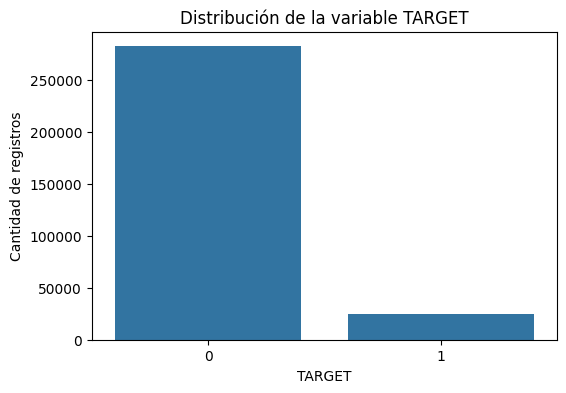

In [213]:
#Gráfico de barras de la variable TARGET
plt.figure(figsize=(6,4))
sns.countplot(x='TARGET', data=df)
plt.title('Distribución de la variable TARGET')
plt.xlabel('TARGET')
plt.ylabel('Cantidad de registros')
plt.show()

El gráfico de barras muestra visualmente la distribución de la variable objetivo. Se observa que la clase 0 tiene una cantidad mucho mayor de registros que la clase 1, lo cual evidencia un desbalance en los datos.

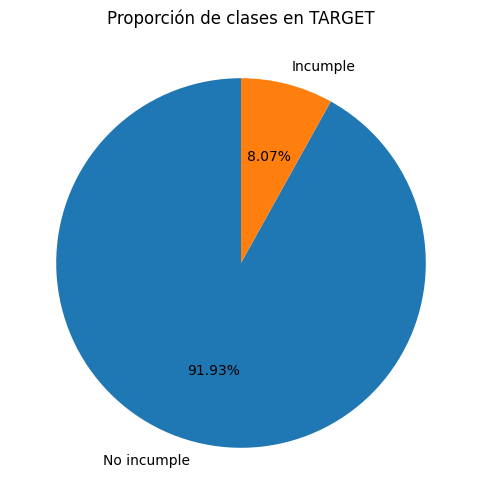

In [214]:
#Gráfico de pastel de la variable TARGET
plt.figure(figsize=(6,6))
df['TARGET'].value_counts().plot.pie(
    autopct='%1.2f%%',
    labels=['No incumple', 'Incumple'],
    startangle=90
)
plt.title('Proporción de clases en TARGET')
plt.ylabel('')
plt.show()

El gráfico de pastel permite observar la proporción porcentual de cada clase. La clase 0, correspondiente a clientes que no incumplen, representa la mayor parte del dataset. Por otro lado, la clase 1, correspondiente a clientes que incumplen, representa una proporción mucho menor.

In [215]:
#Resumen del desbalance de clases
total_registros = len(df)
clase_0 = conteo_target[0]
clase_1 = conteo_target[1]

porcentaje_0 = proporcion_target[0]
porcentaje_1 = proporcion_target[1]

ratio_desbalance = clase_0 / clase_1

print(f"Total de registros: {total_registros}")
print(f"Clientes que no incumplen TARGET=0: {clase_0} ({porcentaje_0:.2f}%)")
print(f"Clientes que incumplen TARGET=1: {clase_1} ({porcentaje_1:.2f}%)")
print(f"Ratio de desbalance clase 0 / clase 1: {ratio_desbalance:.2f}")

Total de registros: 307511
Clientes que no incumplen TARGET=0: 282686 (91.93%)
Clientes que incumplen TARGET=1: 24825 (8.07%)
Ratio de desbalance clase 0 / clase 1: 11.39


El dataset presenta desbalance de clases, debido a que la cantidad de clientes que no incumplen es mucho mayor que la cantidad de clientes que sí incumplen. Esto significa que un modelo predictivo podría aprender a favorecer la clase mayoritaria y obtener una buena precisión general, pero fallar al identificar correctamente a los clientes con riesgo de incumplimiento.

El balanceo de datos consiste en aplicar técnicas que buscan reducir esta diferencia entre clases. Algunas estrategias son el submuestreo de la clase mayoritaria, el sobremuestreo de la clase minoritaria o métodos como SMOTE. En este trabajo, el análisis del desbalance es importante porque la clase 1 representa el evento de mayor interés: detectar clientes con posible incumplimiento crediticio.

Por ello, esta sección permite concluir que el dataset no debe tratarse como si ambas clases tuvieran la misma representación. En etapas posteriores será necesario considerar técnicas de balanceo antes de realizar el ranking predictivo y la evaluación de atributos.

**3. CALIDAD DE LOS DATOS**


In [216]:
#Cantidad de valores nulos por columna
valores_nulos = df.isnull().sum()

#Porcentaje de valores nulos
porcentaje_nulos = (valores_nulos / len(df)) * 100

#Crear tabla resumen
tabla_nulos = pd.DataFrame({

    'Valores Nulos': valores_nulos,
    'Porcentaje Nulos (%)': porcentaje_nulos

})

#Ordenar de mayor a menor
tabla_nulos = tabla_nulos.sort_values(
    by='Porcentaje Nulos (%)',
    ascending=False
)

#Mostrar columnas con nulos
tabla_nulos[tabla_nulos['Valores Nulos'] > 0].head(30)

,Valores Nulos,Porcentaje Nulos (%)
COMMONAREA_AVG,214865,69.872297
COMMONAREA_MODE,214865,69.872297
COMMONAREA_MEDI,214865,69.872297
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_AVG,213514,69.432963
FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_AVG,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953
LIVINGAPARTMENTS_MODE,210199,68.354953


Se identificaron las columnas con valores faltantes y se calculó el porcentaje de nulos respecto al total de registros. Este análisis es importante porque algunas variables pueden presentar una gran cantidad de información incompleta, lo cual afecta la calidad del dataset y puede perjudicar el rendimiento de los modelos predictivos.

Además, conocer el porcentaje de valores faltantes ayuda a decidir posteriormente si una columna debe eliminarse, imputarse o mantenerse sin modificaciones.

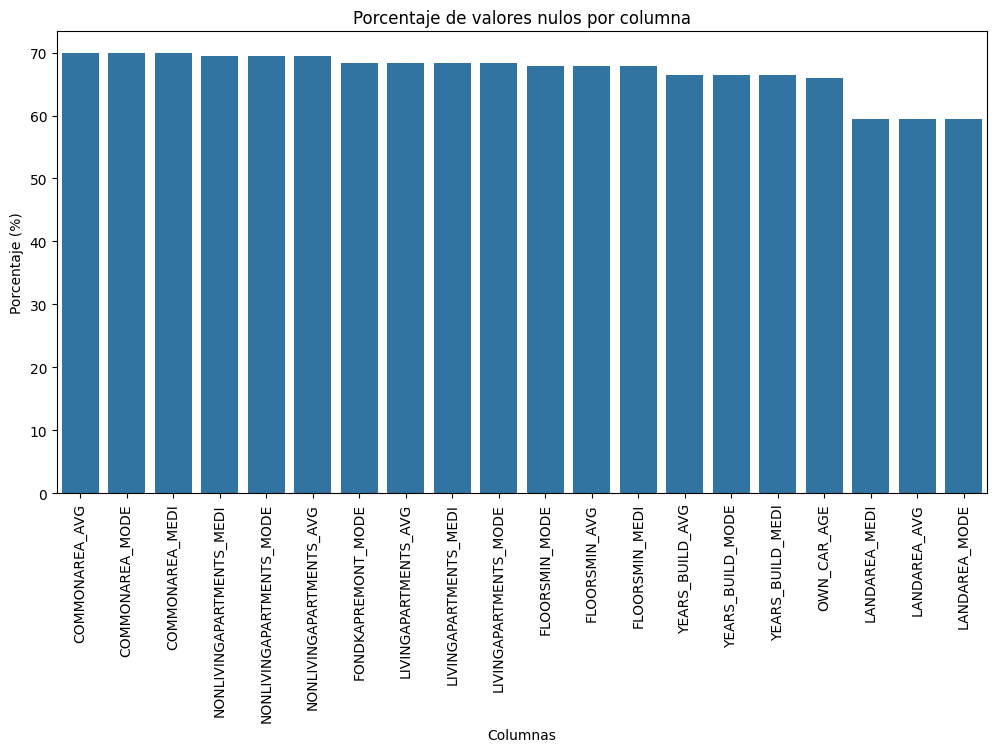

In [217]:
#Visualización de porcentaje de nulos
plt.figure(figsize=(12,6))

tabla_nulos_filtrada = tabla_nulos[
    tabla_nulos['Porcentaje Nulos (%)'] > 0
].head(20)

sns.barplot(

    x=tabla_nulos_filtrada.index,
    y=tabla_nulos_filtrada['Porcentaje Nulos (%)']

)

plt.xticks(rotation=90)
plt.title('Porcentaje de valores nulos por columna')
plt.ylabel('Porcentaje (%)')
plt.xlabel('Columnas')

plt.show()

El gráfico permite visualizar las columnas con mayor porcentaje de datos faltantes. Algunas variables presentan niveles muy altos de ausencia de información, lo que indica que podrían no aportar suficiente valor al análisis y posiblemente deban eliminarse en la etapa de limpieza.

In [218]:
#Cantidad de filas con al menos un valor nulo
filas_con_nulos = df.isnull().any(axis=1).sum()

print(f"Cantidad de filas con valores nulos: {filas_con_nulos}")

Cantidad de filas con valores nulos: 298909


Se contabilizaron las filas que contienen al menos un valor faltante. Esto permite estimar qué tan extendido se encuentra el problema de datos incompletos dentro del dataset.

In [219]:
#Porcentaje de filas con al menos un valor nulo
porcentaje_filas_nulas = (filas_con_nulos / len(df)) * 100

print(f"Porcentaje de filas con valores nulos: {porcentaje_filas_nulas:.2f}%")

Porcentaje de filas con valores nulos: 97.20%


El porcentaje de filas con valores faltantes permite evaluar si la ausencia de datos afecta únicamente a ciertas columnas específicas o si el problema está distribuido en gran parte de los registros del dataset.

In [220]:
#Detección de filas duplicadas
duplicados = df.duplicated().sum()

print(f"Cantidad de filas duplicadas: {duplicados}")

Cantidad de filas duplicadas: 0


Se verificó la existencia de registros duplicados en el dataset. Los duplicados pueden generar sesgos durante el entrenamiento de modelos predictivos y alterar los resultados estadísticos del análisis.

In [221]:
#Columnas con una sola categoría
columnas_constantes = []

for col in df.columns:

    if df[col].nunique() == 1:
        columnas_constantes.append(col)

print("Columnas con una sola categoría:")
print(columnas_constantes)

Columnas con una sola categoría:
[]


Las columnas con una sola categoría no aportan información útil para el análisis predictivo, debido a que todos los registros presentan el mismo valor. Por ello, estas variables suelen eliminarse durante el proceso de limpieza de datos.

In [222]:
#Seleccionar variables numéricas
variables_numericas = df.select_dtypes(include=['int64', 'float64']).columns

#Resumen estadístico
df[variables_numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,278180.518577,102790.175348,100002.0,189145.5,278202.0,367142.5,456255.0
TARGET,307511.0,0.080729,0.272419,0.0,0.0,0.0,0.0,1.0
CNT_CHILDREN,307511.0,0.417052,0.722121,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0
...,...,...,...,...,...,...,...,...
AMT_REQ_CREDIT_BUREAU_DAY,265992.0,0.007000,0.110757,0.0,0.0,0.0,0.0,9.0
AMT_REQ_CREDIT_BUREAU_WEEK,265992.0,0.034362,0.204685,0.0,0.0,0.0,0.0,8.0
AMT_REQ_CREDIT_BUREAU_MON,265992.0,0.267395,0.916002,0.0,0.0,0.0,0.0,27.0
AMT_REQ_CREDIT_BUREAU_QRT,265992.0,0.265474,0.794056,0.0,0.0,0.0,0.0,261.0


El resumen estadístico de las variables numéricas permite detectar posibles valores extremos o inconsistentes. Variables con máximos muy alejados de la media pueden indicar la presencia de outliers.

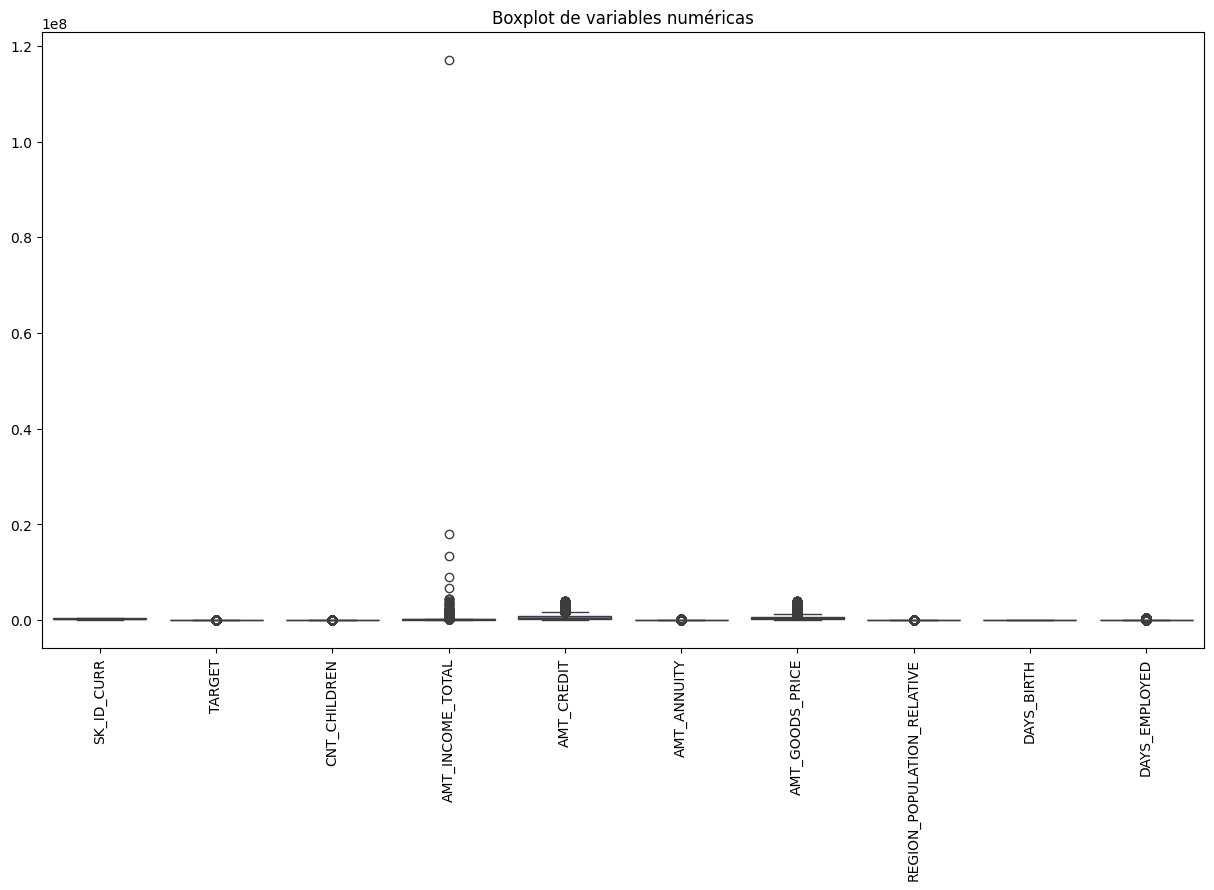

In [223]:
#Visualización de outliers con boxplots
plt.figure(figsize=(15,8))

sns.boxplot(data=df[variables_numericas[:10]])

plt.xticks(rotation=90)
plt.title('Boxplot de variables numéricas')

plt.show()

Los diagramas de caja permiten visualizar la dispersión de las variables numéricas y detectar valores atípicos. Los puntos alejados de la caja representan posibles outliers, los cuales podrían afectar el comportamiento de algoritmos de aprendizaje automático.

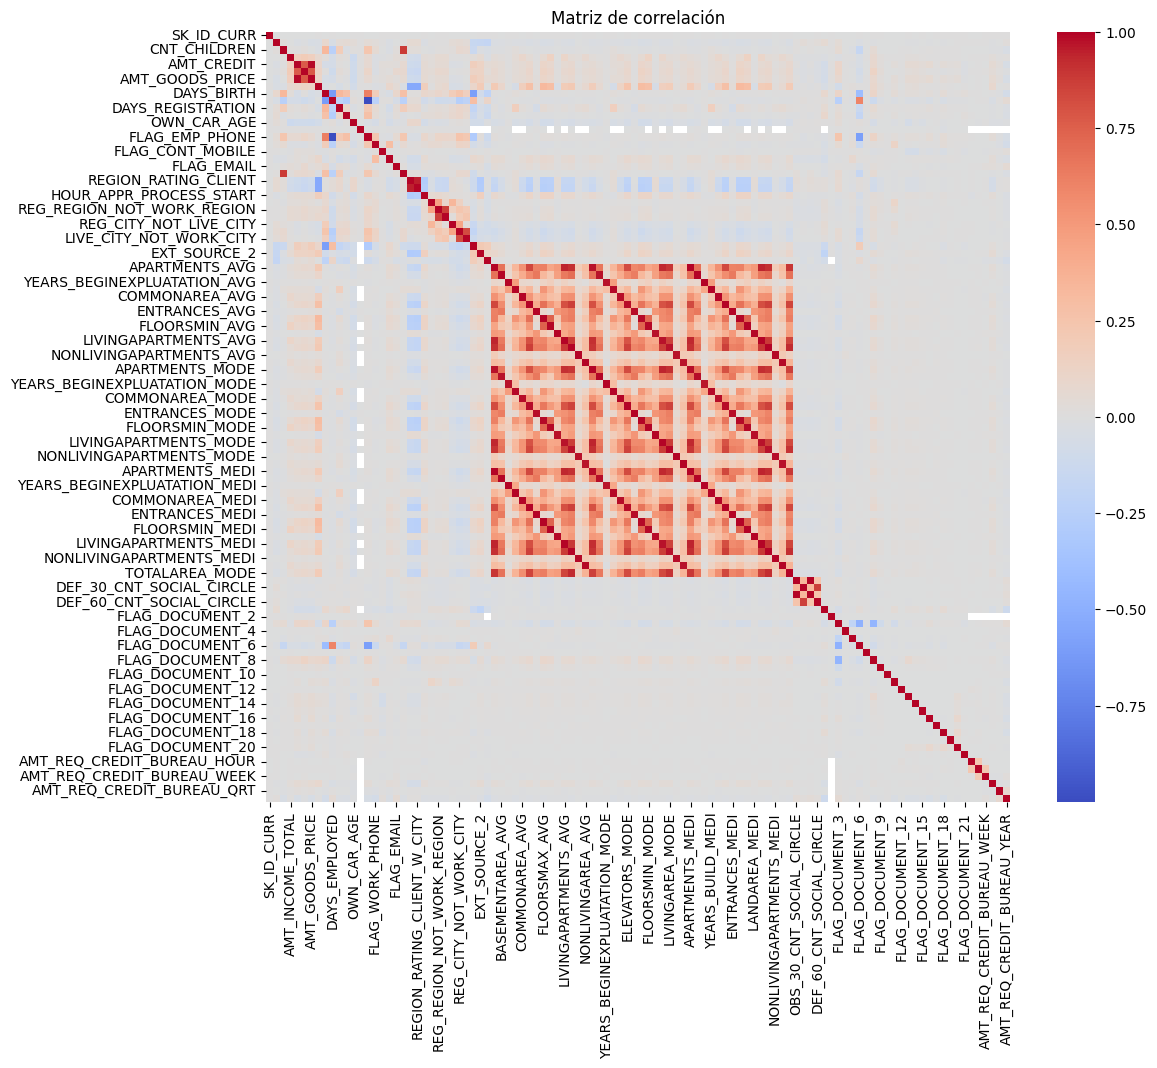

In [224]:
#Matriz de correlación
correlacion = df[variables_numericas].corr()

plt.figure(figsize=(12,10))

sns.heatmap(

    correlacion,
    cmap='coolwarm',
    center=0

)

plt.title('Matriz de correlación')

plt.show()

La matriz de correlación permite analizar la relación entre variables numéricas. Esta herramienta es útil para detectar atributos altamente relacionados entre sí, lo cual puede influir posteriormente en la selección de variables y en la construcción de modelos predictivos.

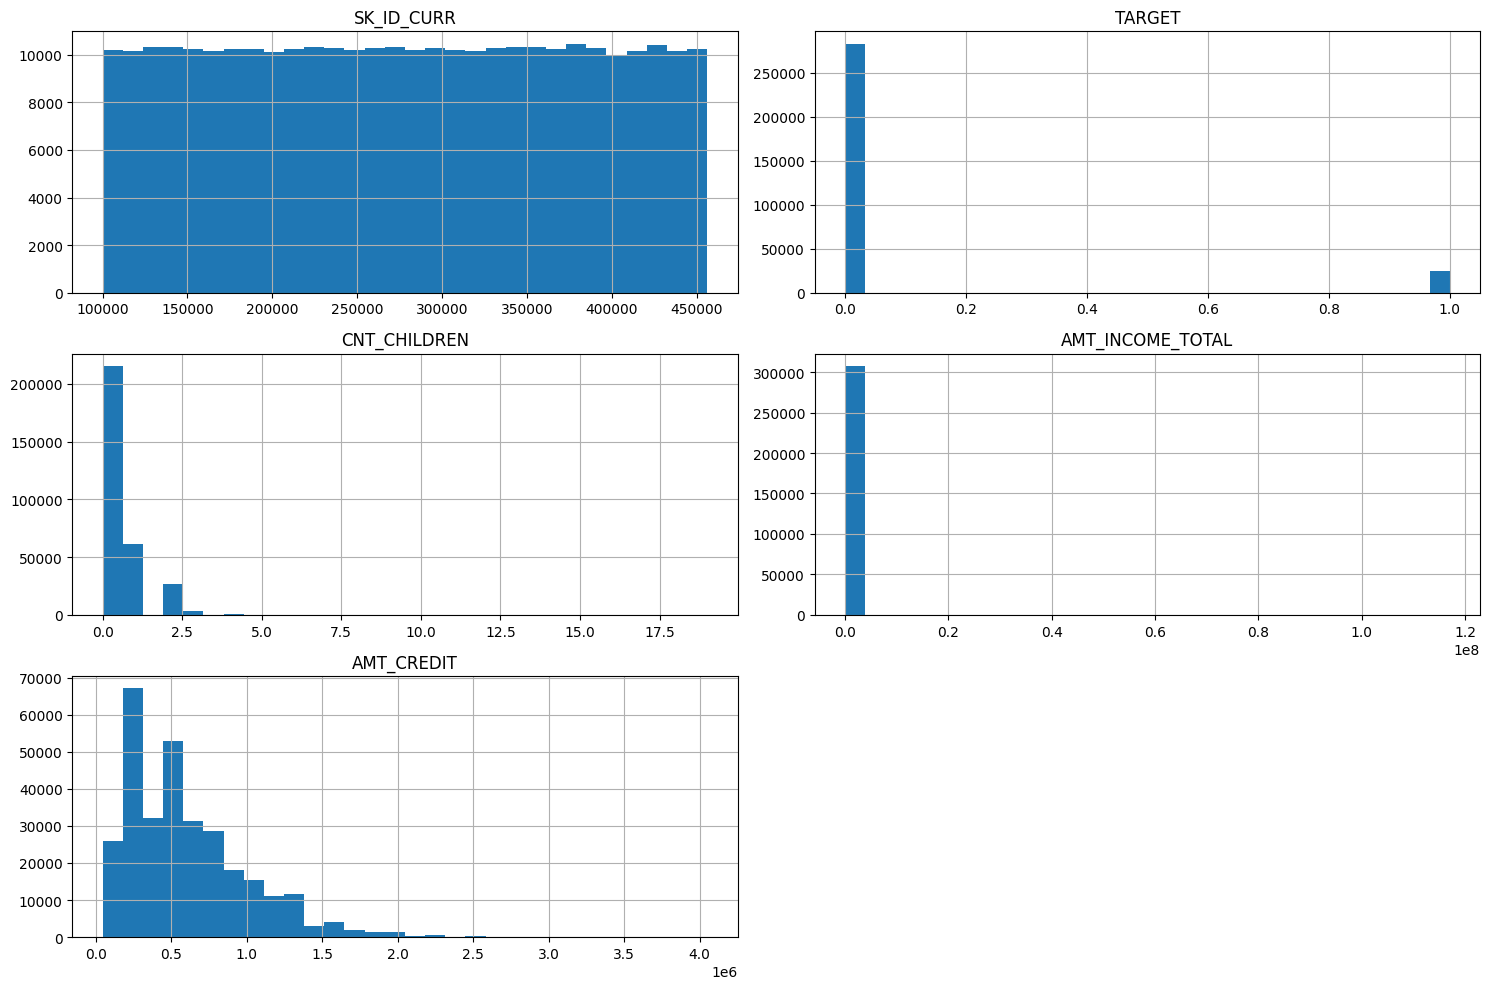

In [225]:
#Distribución de algunas variables numéricas
df[variables_numericas[:5]].hist(

    figsize=(15,10),
    bins=30

)

plt.tight_layout()
plt.show()

Los histogramas permiten analizar la distribución de las variables numéricas. Algunas variables pueden presentar distribuciones sesgadas, acumulaciones de valores o comportamientos anómalos, aspectos importantes para decidir estrategias de transformación y limpieza.

In [226]:
#Resumen general de calidad de datos
print("Resumen de calidad de datos")
print("--------------------------------")
print(f"Cantidad de filas: {df.shape[0]}")
print(f"Cantidad de columnas: {df.shape[1]}")
print(f"Filas duplicadas: {duplicados}")
print(f"Filas con nulos: {filas_con_nulos}")
print(f"Columnas con una sola categoría: {len(columnas_constantes)}")

Resumen de calidad de datos
--------------------------------
Cantidad de filas: 307511
Cantidad de columnas: 122
Filas duplicadas: 0
Filas con nulos: 298909
Columnas con una sola categoría: 0


El análisis de calidad de datos permitió identificar problemas importantes dentro del dataset, principalmente relacionados con valores faltantes y presencia de posibles outliers. También se verificó la existencia de columnas poco informativas y se analizó la distribución de las variables numéricas.
Esta etapa es fundamental porque permite preparar adecuadamente los datos antes de realizar transformaciones, balanceo o modelado predictivo. Un dataset con problemas de calidad puede generar resultados poco confiables y afectar negativamente el desempeño de los modelos de análisis.

**4. LIMPIEZA DE LOS DATOS**

In [227]:
#Crear copia del dataset original
df_limpio = df.copy()

Antes de iniciar el proceso de limpieza se creó una copia del dataset original. Esto permite conservar intactos los datos iniciales y trabajar sobre una versión independiente donde se aplicarán las transformaciones necesarias.

In [228]:
#Porcentaje de valores nulos por columna
porcentaje_nulos = (df_limpio.isnull().sum() / len(df_limpio)) * 100

#Columnas con más de 50% de valores nulos
columnas_eliminar = porcentaje_nulos[porcentaje_nulos > 50].index

print("Columnas eliminadas por exceso de nulos:")
print(columnas_eliminar)

Columnas eliminadas por exceso de nulos:
Index(['OWN_CAR_AGE', 'EXT_SOURCE_1', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG',
       'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG',
       'FLOORSMIN_AVG', 'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG',
       'LIVINGAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG',
       'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BUILD_MODE',
       'COMMONAREA_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMIN_MODE',
       'LANDAREA_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAREA_MODE',
       'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAREA_MODE', 'APARTMENTS_MEDI',
       'BASEMENTAREA_MEDI', 'YEARS_BUILD_MEDI', 'COMMONAREA_MEDI',
       'ELEVATORS_MEDI', 'ENTRANCES_MEDI', 'FLOORSMIN_MEDI', 'LANDAREA_MEDI',
       'LIVINGAPARTMENTS_MEDI', 'LIVINGAREA_MEDI', 'NONLIVINGAPARTMENTS_MEDI',
       'NONLIVINGAREA_MEDI', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE',
       'WALLSMATERIAL_MODE'],
      dtype='object')


Se identificaron las columnas que presentan más del 50% de valores faltantes. Estas variables contienen una gran cantidad de información incompleta, por lo que podrían aportar poco valor al análisis y dificultar el proceso de modelado.

In [229]:
#Eliminar columnas con demasiados nulos
df_limpio.drop(columns=columnas_eliminar, inplace=True)

print(f"Nueva cantidad de columnas: {df_limpio.shape[1]}")

Nueva cantidad de columnas: 81


Se eliminaron las columnas con un porcentaje excesivo de datos faltantes. Esta estrategia ayuda a reducir ruido dentro del dataset y facilita las etapas posteriores de análisis y transformación.

In [230]:
#Separar variables numéricas y categóricas, excluyendo TARGET
variables_numericas = df_limpio.select_dtypes(
    include=['int64', 'float64']
).columns.drop('TARGET')

variables_categoricas = df_limpio.select_dtypes(
    include=['object']
).columns

Las variables fueron separadas según su tipo de dato para aplicar diferentes estrategias de imputación. Las variables numéricas y categóricas requieren tratamientos distintos debido a la naturaleza de sus datos.

In [231]:
#Rellenar valores faltantes en variables numéricas con la mediana
imputador_numerico = SimpleImputer(strategy='median')

df_limpio[variables_numericas] = imputador_numerico.fit_transform(
    df_limpio[variables_numericas]
)

Los valores faltantes de las variables numéricas fueron reemplazados utilizando la mediana. Esta medida es adecuada porque es menos sensible a valores extremos en comparación con la media.

In [232]:
#Rellenar valores faltantes en variables categóricas con la moda
imputador_categorico = SimpleImputer(strategy='most_frequent')

df_limpio[variables_categoricas] = imputador_categorico.fit_transform(
    df_limpio[variables_categoricas]
)

Los valores faltantes de las variables categóricas fueron reemplazados utilizando la moda, es decir, el valor más frecuente de cada columna. Esta técnica permite mantener la coherencia de las categorías originales.

In [233]:
#Verificar si aún existen valores nulos
nulos_restantes = df_limpio.isnull().sum().sum()

print(f"Cantidad total de nulos restantes: {nulos_restantes}")

Cantidad total de nulos restantes: 0


Después de aplicar la imputación de datos faltantes, se verificó la cantidad total de valores nulos restantes en el dataset para confirmar que el procedimiento de limpieza fue aplicado correctamente.

In [234]:
#Tratamiento de outliers usando IQR, excluyendo TARGET
for col in variables_numericas:

    Q1 = df_limpio[col].quantile(0.25)
    Q3 = df_limpio[col].quantile(0.75)

    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    df_limpio[col] = np.where(
        df_limpio[col] < limite_inferior,
        limite_inferior,
        df_limpio[col]
    )

    df_limpio[col] = np.where(
        df_limpio[col] > limite_superior,
        limite_superior,
        df_limpio[col]
    )

#Verificar que TARGET no fue modificado
df_limpio['TARGET'].value_counts()

,count
TARGET,
0,282686
1,24825


Para tratar los valores extremos se utilizó el método del rango intercuartílico (IQR). Este procedimiento permite limitar los valores demasiado alejados de la distribución principal sin eliminar registros completos del dataset.

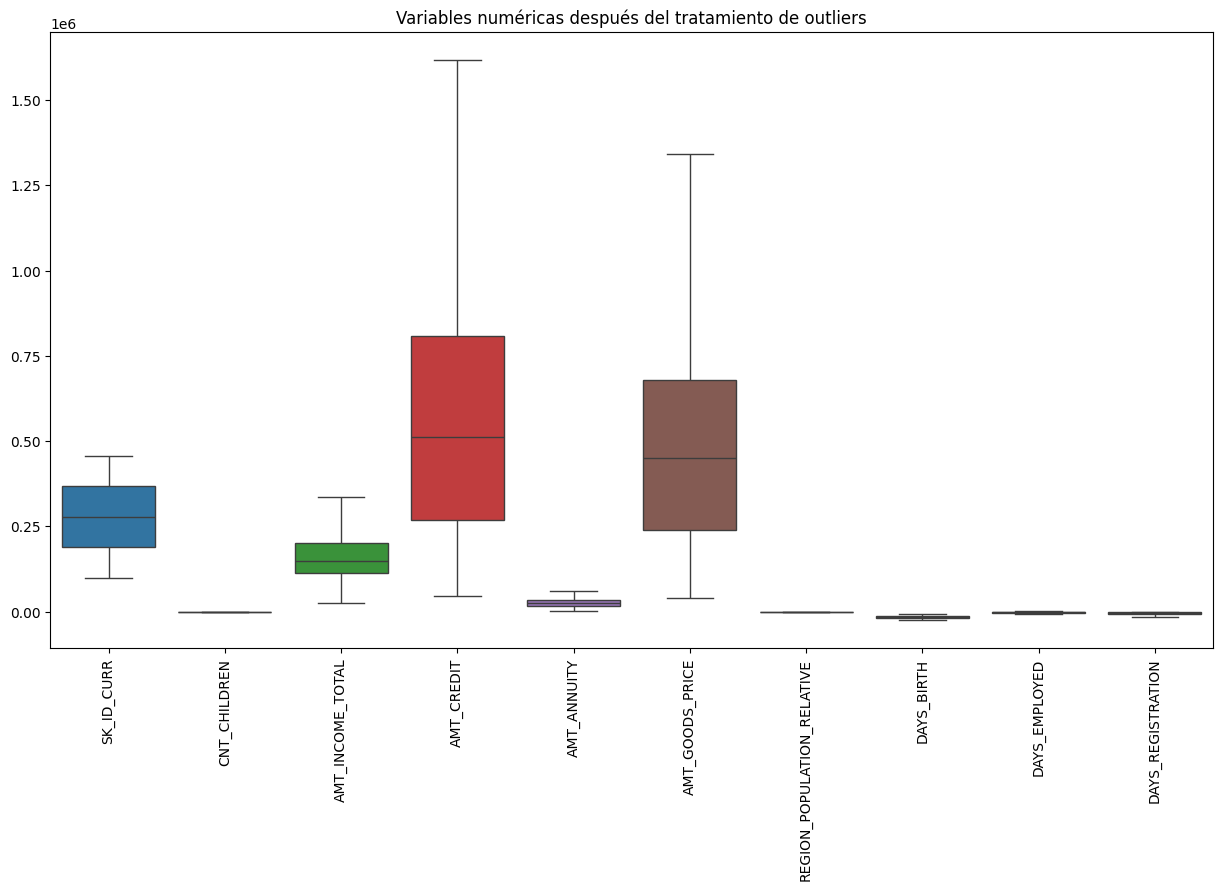

In [235]:
#Boxplot después del tratamiento de outliers
plt.figure(figsize=(15,8))

sns.boxplot(data=df_limpio[variables_numericas[:10]])

plt.xticks(rotation=90)
plt.title('Variables numéricas después del tratamiento de outliers')

plt.show()

El diagrama de caja posterior al tratamiento de outliers permite comparar la distribución de las variables numéricas antes y después de la limpieza. Se observa una reducción de valores extremos, lo cual mejora la estabilidad del dataset para posteriores análisis.

In [236]:
#Verificar dimensiones finales del dataset limpio
print(f"Filas del dataset limpio: {df_limpio.shape[0]}")
print(f"Columnas del dataset limpio: {df_limpio.shape[1]}")

Filas del dataset limpio: 307511
Columnas del dataset limpio: 81


Luego del proceso de limpieza, el dataset conserva la misma cantidad de registros, pero presenta una menor cantidad de columnas debido a la eliminación de variables con demasiados valores nulos.

In [237]:
#Resumen estadístico después de la limpieza
df_limpio.describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,278180.518577,102790.175348,100002.0,189145.5,278202.0,367142.5,456255.0
TARGET,307511.0,0.080729,0.272419,0.0,0.0,0.0,0.0,1.0
CNT_CHILDREN,307511.0,0.407455,0.683742,0.0,0.0,0.0,1.0,2.5
AMT_INCOME_TOTAL,307511.0,162626.947877,73303.150927,25650.0,112500.0,147150.0,202500.0,337500.0
AMT_CREDIT,307511.0,592313.037054,380316.240537,45000.0,270000.0,513531.0,808650.0,1616625.0
...,...,...,...,...,...,...,...,...
AMT_REQ_CREDIT_BUREAU_DAY,307511.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
AMT_REQ_CREDIT_BUREAU_WEEK,307511.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
AMT_REQ_CREDIT_BUREAU_MON,307511.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
AMT_REQ_CREDIT_BUREAU_QRT,307511.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0


El resumen estadístico posterior a la limpieza permite verificar los cambios realizados en las variables numéricas. Se observa una reducción en el impacto de valores extremos y una mayor consistencia en los datos utilizados para el análisis.

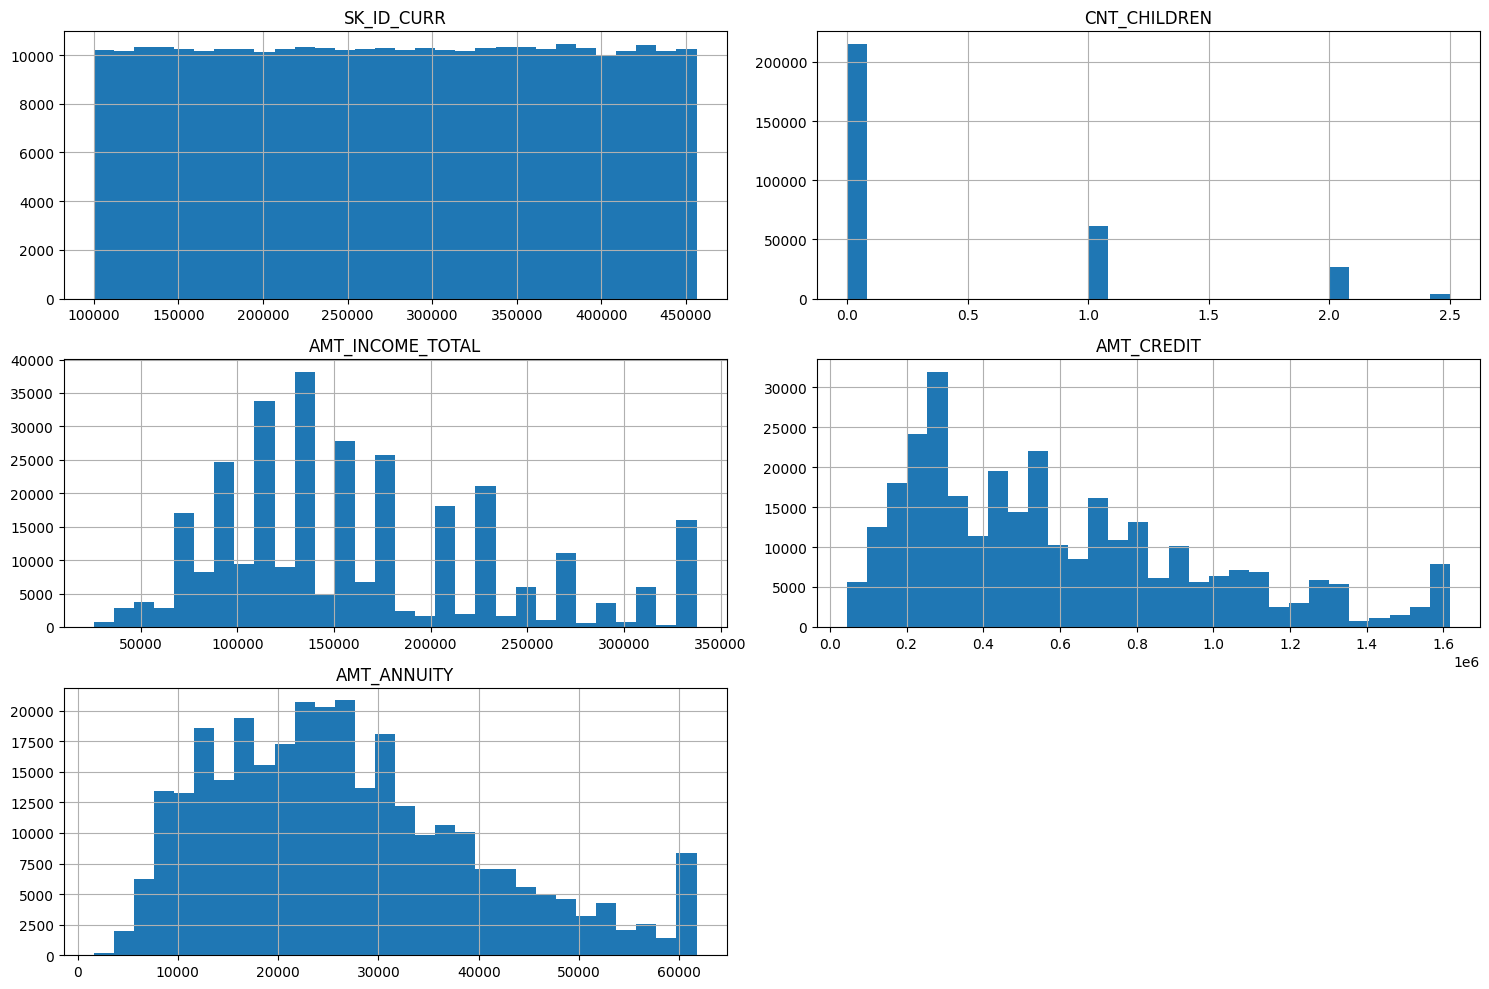

In [238]:
#Histogramas después de la limpieza
df_limpio[variables_numericas[:5]].hist(
    figsize=(15,10),
    bins=30
)

plt.tight_layout()
plt.show()

Los histogramas posteriores a la limpieza permiten analizar nuevamente la distribución de las variables numéricas. Después del tratamiento de nulos y outliers, las distribuciones presentan un comportamiento más estable y adecuado para futuras etapas de modelado y análisis predictivo.

In [239]:
#Resumen final de limpieza
print("Resumen del proceso de limpieza")
print("--------------------------------")
print(f"Columnas eliminadas: {len(columnas_eliminar)}")
print(f"Nulos restantes: {nulos_restantes}")
print(f"Dimensiones finales: {df_limpio.shape}")

Resumen del proceso de limpieza
--------------------------------
Columnas eliminadas: 41
Nulos restantes: 0
Dimensiones finales: (307511, 81)


El proceso de limpieza permitió mejorar la calidad general del dataset mediante la eliminación de columnas con demasiados valores faltantes, la imputación de datos incompletos y el tratamiento de valores extremos.
Estas transformaciones son importantes porque preparan el dataset para etapas posteriores como la conversión de variables categóricas, el balanceo de clases y el análisis predictivo. Un dataset limpio reduce errores, mejora la estabilidad de los modelos y permite obtener resultados más confiables.

**5. CONVERSIÓN DE ATRIBUTOS CATEGÓRICOS EN NUMÉRICOS**

In [240]:
#Crear copia del dataset limpio
df_codificado = df_limpio.copy()

Luego de finalizar el proceso de limpieza de datos, se creó una nueva copia del dataset para realizar la conversión de variables categóricas a variables numéricas. Esta transformación es necesaria porque la mayoría de algoritmos de análisis y aprendizaje automático trabajan únicamente con datos numéricos.

In [241]:
#Identificar columnas categóricas
columnas_categoricas = df_codificado.select_dtypes(
    include=['object']
).columns

print("Columnas categóricas:")
print(columnas_categoricas)

Columnas categóricas:
Index(['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE',
       'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE',
       'EMERGENCYSTATE_MODE'],
      dtype='object')


Se identificaron las columnas categóricas presentes en el dataset. Estas variables contienen texto o categorías y requieren un proceso de codificación para poder ser utilizadas en análisis estadísticos y modelos predictivos.

In [242]:
#Cantidad de columnas antes de la codificación
columnas_antes = df_codificado.shape[1]

print(f"Cantidad de columnas antes de codificar: {columnas_antes}")

Cantidad de columnas antes de codificar: 81


Antes de realizar la codificación se registró la cantidad total de columnas del dataset. Esto permitirá posteriormente comparar el impacto de la transformación sobre la dimensionalidad de los datos.

In [243]:
#Aplicar One-Hot Encoding
df_codificado = pd.get_dummies(

    df_codificado,
    columns=columnas_categoricas,
    drop_first=True

)

#Convertir columnas booleanas a enteros 0 y 1
columnas_booleanas = df_codificado.select_dtypes(include=['bool']).columns

df_codificado[columnas_booleanas] = df_codificado[columnas_booleanas].astype(int)

Se utilizó la técnica One-Hot Encoding para convertir las variables categóricas en variables binarias numéricas. Este método crea nuevas columnas para representar cada categoría posible mediante valores 0 y 1.

Además, se utilizó el parámetro drop_first=True para evitar redundancia entre variables y reducir problemas de multicolinealidad.

In [244]:
#Cantidad de columnas después de la codificación
columnas_despues = df_codificado.shape[1]

print(f"Cantidad de columnas después de codificar: {columnas_despues}")

Cantidad de columnas después de codificar: 181


Después de aplicar One-Hot Encoding se observó un incremento en la cantidad de columnas del dataset. Esto ocurre porque cada categoría se transforma en una nueva variable binaria independiente.

In [245]:
#Cantidad de nuevas columnas generadas
nuevas_columnas = columnas_despues - columnas_antes

print(f"Nuevas columnas generadas: {nuevas_columnas}")

Nuevas columnas generadas: 100


El número de nuevas columnas generadas permite medir el impacto de la codificación sobre la dimensionalidad del dataset. Un aumento considerable de columnas puede incrementar el costo computacional y afectar algunos algoritmos de análisis.

In [246]:
#Visualizar parte del dataset codificado
df_codificado.head()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,ORGANIZATION_TYPE_Trade: type 5,ORGANIZATION_TYPE_Trade: type 6,ORGANIZATION_TYPE_Trade: type 7,ORGANIZATION_TYPE_Transport: type 1,ORGANIZATION_TYPE_Transport: type 2,ORGANIZATION_TYPE_Transport: type 3,ORGANIZATION_TYPE_Transport: type 4,ORGANIZATION_TYPE_University,ORGANIZATION_TYPE_XNA,EMERGENCYSTATE_MODE_Yes
0,100002.0,1,0.0,202500.0,406597.5,24700.5,351000.0,0.018801,-9461.0,-637.0,...,0,0,0,0,0,0,0,0,0,0
1,100003.0,0,0.0,270000.0,1293502.5,35698.5,1129500.0,0.003541,-16765.0,-1188.0,...,0,0,0,0,0,0,0,0,0,0
2,100004.0,0,0.0,67500.0,135000.0,6750.0,135000.0,0.010032,-19046.0,-225.0,...,0,0,0,0,0,0,0,0,0,0
3,100006.0,0,0.0,135000.0,312682.5,29686.5,297000.0,0.008019,-19005.0,-3039.0,...,0,0,0,0,0,0,0,0,0,0
4,100007.0,0,0.0,121500.0,513000.0,21865.5,513000.0,0.028663,-19932.0,-3038.0,...,0,0,0,0,0,0,0,0,0,0


La visualización del dataset codificado permite verificar que las variables categóricas fueron correctamente transformadas en atributos numéricos binarios.

In [247]:
#Verificar tipos de datos después de la conversión
df_codificado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 181 entries, SK_ID_CURR to EMERGENCYSTATE_MODE_Yes
dtypes: float64(67), int64(114)
memory usage: 424.6 MB


Después de la conversión se verificó nuevamente el tipo de dato de las columnas. Se observa que las variables categóricas originales fueron reemplazadas por variables numéricas compatibles con procesos de análisis predictivo.

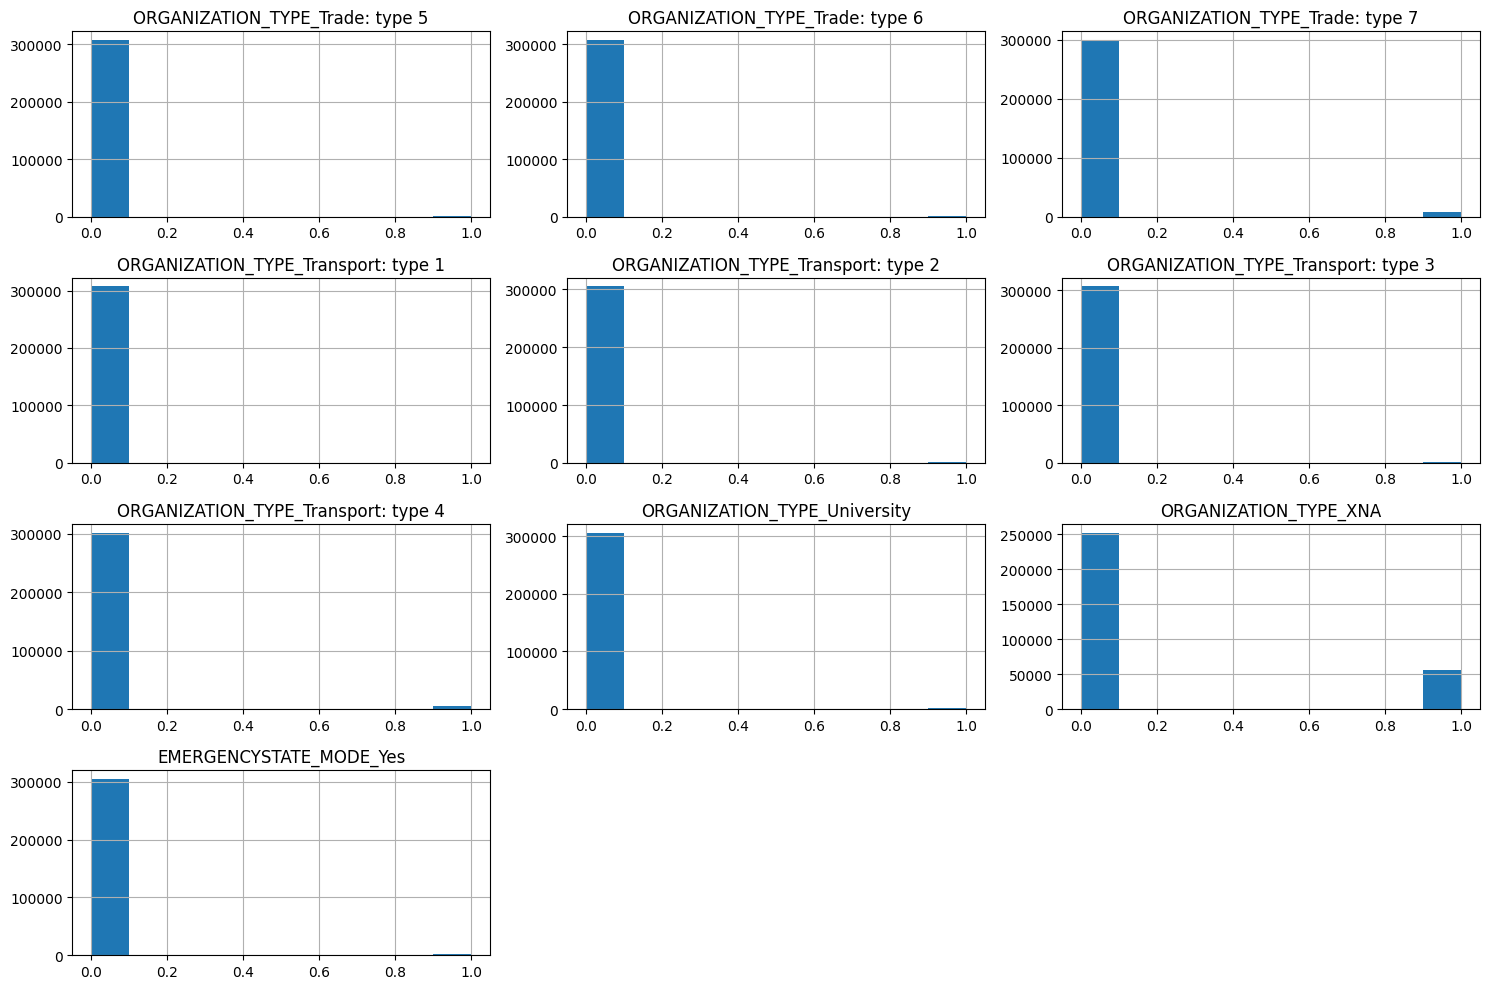

In [248]:
#Distribución de algunas variables codificadas
df_codificado.iloc[:, -10:].hist(

    figsize=(15,10),
    bins=10

)

plt.tight_layout()
plt.show()

Los histogramas de las variables codificadas permiten observar el comportamiento de las nuevas columnas binarias generadas mediante One-Hot Encoding. Estas variables presentan principalmente valores 0 y 1, correspondientes a la presencia o ausencia de una categoría específica.

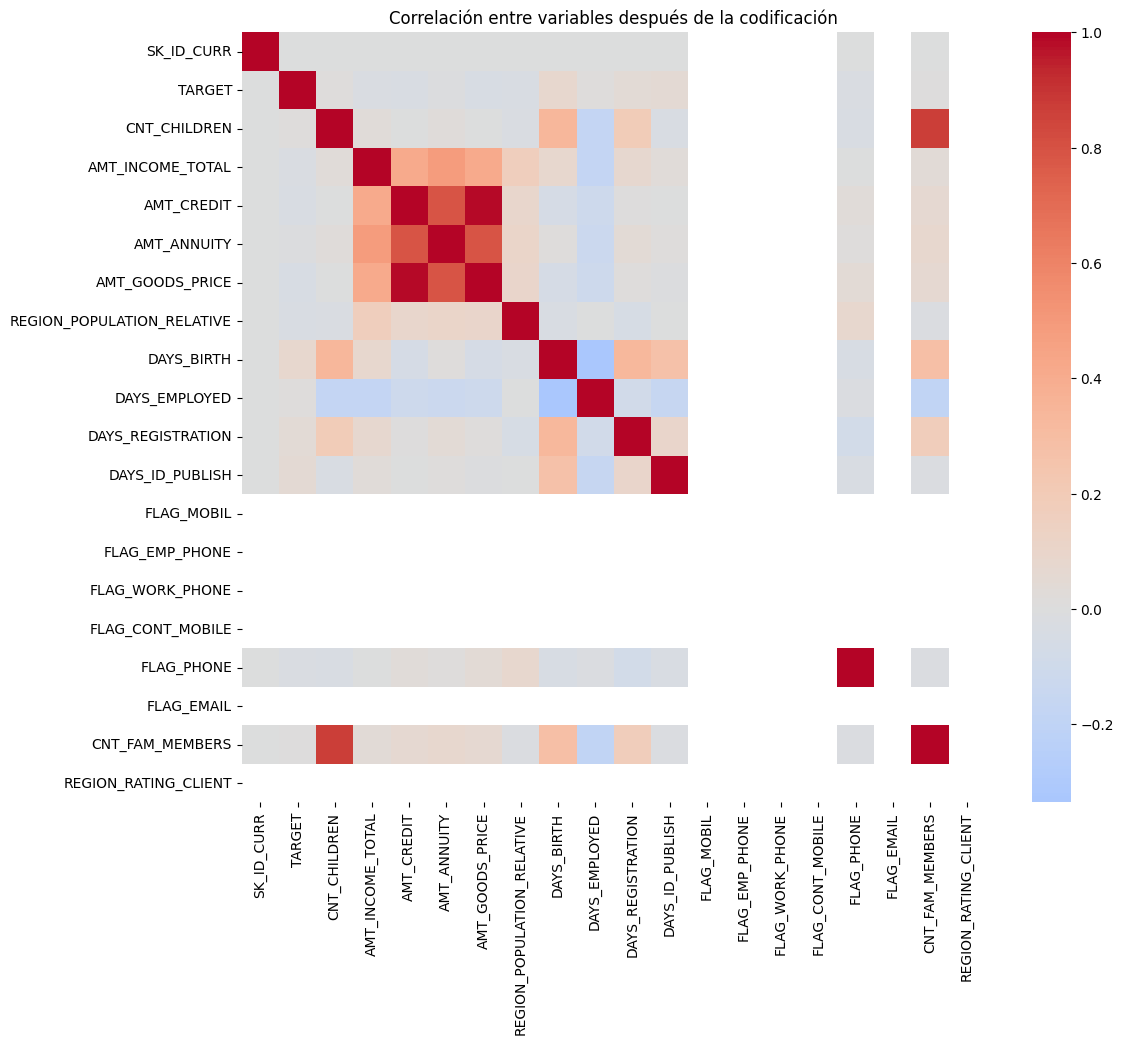

In [249]:
#Matriz de correlación después de la codificación
plt.figure(figsize=(12,10))

correlacion_codificada = df_codificado.corr()

sns.heatmap(

    correlacion_codificada.iloc[:20, :20],
    cmap='coolwarm',
    center=0

)

plt.title('Correlación entre variables después de la codificación')

plt.show()

La matriz de correlación posterior a la codificación permite observar relaciones entre variables numéricas y atributos binarios generados. Este análisis es útil para detectar asociaciones importantes entre variables antes de realizar procesos de selección de atributos o modelado predictivo.

In [250]:
#Verificar dimensiones finales del dataset codificado
print(f"Filas del dataset codificado: {df_codificado.shape[0]}")
print(f"Columnas del dataset codificado: {df_codificado.shape[1]}")

Filas del dataset codificado: 307511
Columnas del dataset codificado: 181


El dataset final mantiene la misma cantidad de registros, pero presenta una mayor cantidad de columnas debido al proceso de codificación categórica. Esto confirma que las variables categóricas fueron conservadas mediante su transformación a formato numérico.

In [251]:
# Agrega el nombre del archivo al final de la ruta
ruta_salida = '/content/drive/MyDrive/PC2/DATOS GENERADOS/application_train_codificado.csv'

df_codificado.to_csv(ruta_salida, index=False)

print("Dataset exportado correctamente")

Dataset exportado correctamente


El dataset procesado fue exportado en formato CSV como respaldo del proceso realizado. Sin embargo, el ranking de atributos también será desarrollado directamente en el notebook de Python, ya que el docente permitió trabajar esta etapa en Colab en lugar de RapidMiner. Por ello, el archivo exportado servirá como evidencia intermedia del dataset limpio y codificado.

**6. RANKING DE ATRIBUTOS SEGÚN SU CALIDAD PREDICTIVA**

In [252]:
#Separar variables predictoras y variable objetivo
X = df_codificado.drop('TARGET', axis=1)
y = df_codificado['TARGET']

In [253]:
#Verificar si TARGET existe y cómo quedó
print(df_codificado.columns[df_codificado.columns.str.contains('TARGET')])

print(df_codificado['TARGET'].value_counts())

Index(['TARGET'], dtype='object')
TARGET
0    282686
1     24825
Name: count, dtype: int64


Se separó la variable objetivo TARGET de las variables predictoras. Las variables predictoras serán utilizadas para estimar qué atributos tienen mayor capacidad para explicar o diferenciar los casos de incumplimiento y no incumplimiento.

In [254]:
#Balancear los datos usando SMOTE
smote = SMOTE(random_state=42)

X_balanceado, y_balanceado = smote.fit_resample(X, y)

print("Distribución antes del balanceo:")
print(y.value_counts())

print("\nDistribución después del balanceo:")
print(y_balanceado.value_counts())

Distribución antes del balanceo:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Distribución después del balanceo:
TARGET
1    282686
0    282686
Name: count, dtype: int64


Se aplicó SMOTE para balancear la variable objetivo. Esta técnica genera nuevos registros sintéticos de la clase minoritaria, permitiendo que ambas clases tengan una representación más equilibrada. El balanceo es necesario porque el ranking de atributos debe realizarse sobre datos balanceados, tal como indica el enunciado.

In [255]:
#Reconstruir dataset balanceado
df_balanceado = pd.DataFrame(X_balanceado, columns=X.columns)
df_balanceado['TARGET'] = y_balanceado

Luego del balanceo, se reconstruyó el dataset incluyendo nuevamente la variable TARGET. Este dataset balanceado será utilizado para calcular los indicadores de calidad predictiva.

In [256]:
#Indicador 1: Correlación absoluta con TARGET
correlaciones = df_balanceado.corr()['TARGET'].drop('TARGET').abs()

ranking_correlacion = pd.DataFrame({
    'Atributo': correlaciones.index,
    'Correlacion_Absoluta': correlaciones.values
})

ranking_correlacion = ranking_correlacion.sort_values(
    by='Correlacion_Absoluta',
    ascending=False
)

ranking_correlacion.head(20)

,Atributo,Correlacion_Absoluta
27,EXT_SOURCE_2,0.295860
28,EXT_SOURCE_3,0.292862
85,NAME_EDUCATION_TYPE_Higher education,0.292727
70,FLAG_OWN_CAR_Y,0.262748
89,NAME_FAMILY_STATUS_Married,0.255580
80,NAME_INCOME_TYPE_Pensioner,0.247162
178,ORGANIZATION_TYPE_XNA,0.246865
106,OCCUPATION_TYPE_Laborers,0.241365
78,NAME_INCOME_TYPE_Commercial associate,0.234366
116,WEEKDAY_APPR_PROCESS_START_MONDAY,0.214968


El primer indicador utilizado fue la correlación absoluta con la variable TARGET. Este indicador permite medir la intensidad de relación lineal entre cada atributo y la variable objetivo. Mientras mayor sea el valor absoluto de la correlación, mayor será la asociación del atributo con el incumplimiento crediticio.

In [257]:
#Indicador 2: Mutual Information
mi_scores = mutual_info_classif(
    X_balanceado,
    y_balanceado,
    random_state=42
)

ranking_mi = pd.DataFrame({
    'Atributo': X.columns,
    'Mutual_Information': mi_scores
})

ranking_mi = ranking_mi.sort_values(
    by='Mutual_Information',
    ascending=False
)

ranking_mi.head(20)

,Atributo,Mutual_Information
6,REGION_POPULATION_RELATIVE,0.511980
28,EXT_SOURCE_3,0.495798
40,DAYS_LAST_PHONE_CHANGE,0.490547
10,DAYS_ID_PUBLISH,0.487748
8,DAYS_EMPLOYED,0.465704
20,HOUR_APPR_PROCESS_START,0.457745
9,DAYS_REGISTRATION,0.440658
7,DAYS_BIRTH,0.424383
4,AMT_ANNUITY,0.395087
66,AMT_REQ_CREDIT_BUREAU_YEAR,0.358872


El segundo indicador utilizado fue Mutual Information. Este indicador mide cuánta información aporta cada atributo para explicar la variable objetivo. A diferencia de la correlación, puede capturar relaciones no necesariamente lineales entre las variables predictoras y el TARGET.

In [258]:
#Indicador 3: Diferencia de tasas de default
diferencias_default = []

for col in X.columns:

    try:
        grupos = df_balanceado.groupby(pd.qcut(df_balanceado[col], q=5, duplicates='drop'))['TARGET'].mean()
        diferencia = grupos.max() - grupos.min()

        diferencias_default.append({
            'Atributo': col,
            'Diferencia_Tasa_Default': diferencia
        })

    except:
        diferencias_default.append({
            'Atributo': col,
            'Diferencia_Tasa_Default': 0
        })

ranking_default = pd.DataFrame(diferencias_default)

ranking_default = ranking_default.sort_values(
    by='Diferencia_Tasa_Default',
    ascending=False
)

ranking_default.head(20)

,Atributo,Diferencia_Tasa_Default
31,YEARS_BEGINEXPLUATATION_MODE,0.633677
66,AMT_REQ_CREDIT_BUREAU_YEAR,0.589679
29,YEARS_BEGINEXPLUATATION_AVG,0.544964
33,YEARS_BEGINEXPLUATATION_MEDI,0.544421
35,TOTALAREA_MODE,0.507316
27,EXT_SOURCE_2,0.437874
28,EXT_SOURCE_3,0.419960
42,FLAG_DOCUMENT_3,0.299807
20,HOUR_APPR_PROCESS_START,0.292000
7,DAYS_BIRTH,0.285886


El tercer indicador utilizado fue la diferencia de tasas de default. Para cada atributo se agruparon los valores en intervalos y se calculó la diferencia entre la mayor y menor tasa promedio de incumplimiento. Un valor alto indica que el atributo permite distinguir mejor entre clientes con bajo y alto riesgo.

In [259]:
#Unir los tres rankings
ranking_final = ranking_correlacion.merge(
    ranking_mi,
    on='Atributo',
    how='inner'
)

ranking_final = ranking_final.merge(
    ranking_default,
    on='Atributo',
    how='inner'
)

#Normalizar indicadores
ranking_final['Correlacion_norm'] = ranking_final['Correlacion_Absoluta'] / ranking_final['Correlacion_Absoluta'].max()
ranking_final['MI_norm'] = ranking_final['Mutual_Information'] / ranking_final['Mutual_Information'].max()
ranking_final['Default_norm'] = ranking_final['Diferencia_Tasa_Default'] / ranking_final['Diferencia_Tasa_Default'].max()

#Puntaje promedio final
ranking_final['Puntaje_Final'] = (
    ranking_final['Correlacion_norm'] +
    ranking_final['MI_norm'] +
    ranking_final['Default_norm']
) / 3

#Ordenar ranking final
ranking_final = ranking_final.sort_values(
    by='Puntaje_Final',
    ascending=False
)

ranking_final.head(20)

,Atributo,Correlacion_Absoluta,Mutual_Information,Diferencia_Tasa_Default,Correlacion_norm,MI_norm,Default_norm,Puntaje_Final
1,EXT_SOURCE_3,0.292862,0.495798,0.419960,0.989869,0.968393,0.662735,0.873666
0,EXT_SOURCE_2,0.295860,0.129430,0.437874,1.000000,0.252803,0.691005,0.647936
19,DAYS_BIRTH,0.170660,0.424383,0.285886,0.576826,0.828905,0.451155,0.618962
40,DAYS_ID_PUBLISH,0.107765,0.487748,0.276496,0.364242,0.952669,0.436335,0.584415
114,AMT_REQ_CREDIT_BUREAU_YEAR,0.020605,0.358872,0.589679,0.069644,0.700949,0.930568,0.567054
37,DAYS_LAST_PHONE_CHANGE,0.112252,0.490547,0.230343,0.379411,0.958137,0.363502,0.567017
54,REGION_POPULATION_RELATIVE,0.076808,0.511980,0.230802,0.259610,1.000000,0.364227,0.541279
122,YEARS_BEGINEXPLUATATION_MODE,0.016804,0.277667,0.633677,0.056798,0.542340,1.000000,0.533046
80,YEARS_BEGINEXPLUATATION_AVG,0.046675,0.276120,0.544964,0.157761,0.539317,0.860004,0.519027
81,YEARS_BEGINEXPLUATATION_MEDI,0.046382,0.276013,0.544421,0.156770,0.539108,0.859147,0.518342


Se integraron los tres indicadores en un ranking final. Para que los indicadores sean comparables, se normalizaron entre 0 y 1. Luego se calculó un puntaje promedio final para ordenar los atributos según su calidad predictiva. Los atributos ubicados en las primeras posiciones son los que presentan mayor relación con la variable TARGET.

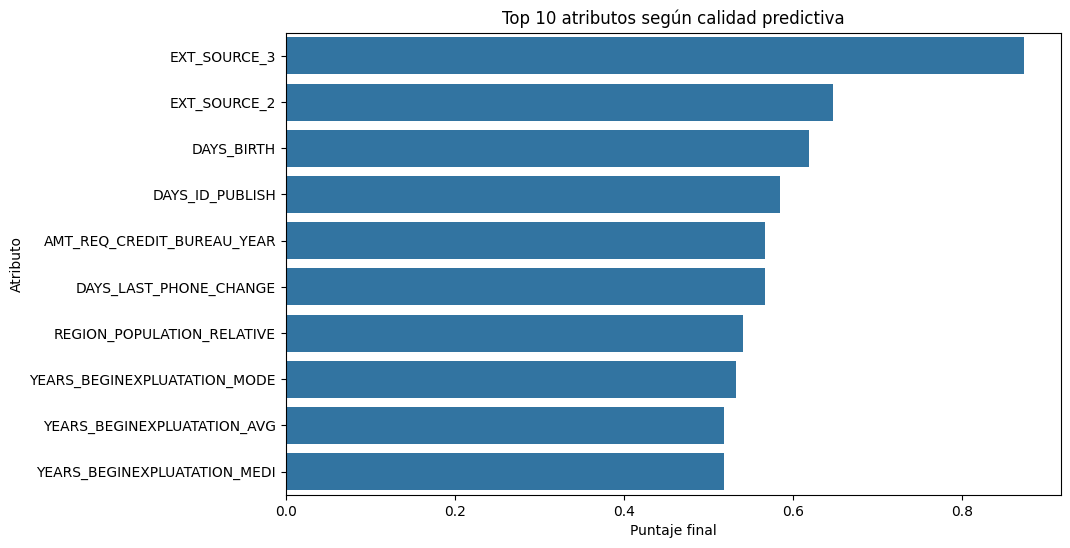

In [260]:
#Gráfico del ranking final de atributos
top_atributos = ranking_final.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_atributos,
    x='Puntaje_Final',
    y='Atributo'
)

plt.title('Top 10 atributos según calidad predictiva')
plt.xlabel('Puntaje final')
plt.ylabel('Atributo')

plt.show()

El gráfico muestra los diez atributos con mayor calidad predictiva según el puntaje final calculado. Estos atributos son los más relevantes para diferenciar entre clientes que incumplen y no incumplen el pago del crédito.

In [261]:
#Seleccionar los 3 mejores atributos
mejores_atributos = ranking_final['Atributo'].head(3).tolist()

print("Mejores atributos seleccionados:")
print(mejores_atributos)

Mejores atributos seleccionados:
['EXT_SOURCE_3', 'EXT_SOURCE_2', 'DAYS_BIRTH']


Se seleccionaron los tres mejores atributos del ranking final para analizarlos con mayor detalle mediante histogramas separados por clase de la variable objetivo.

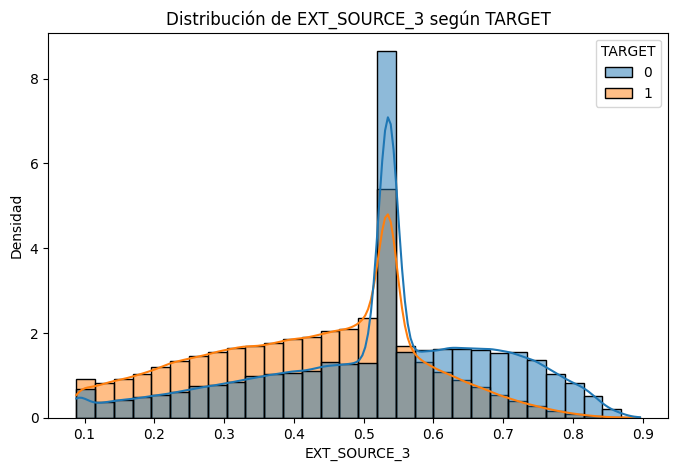

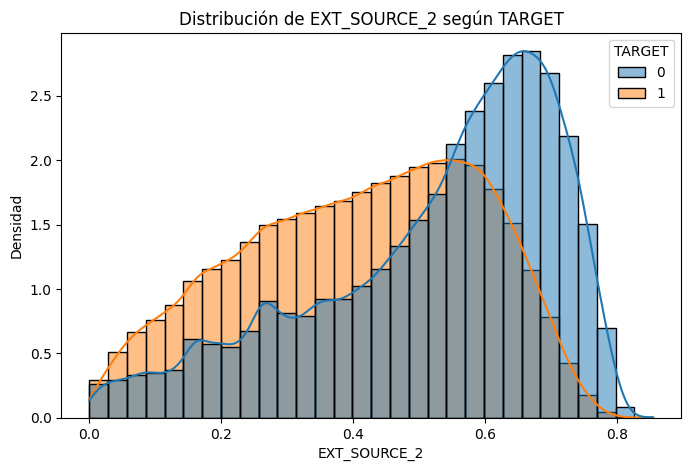

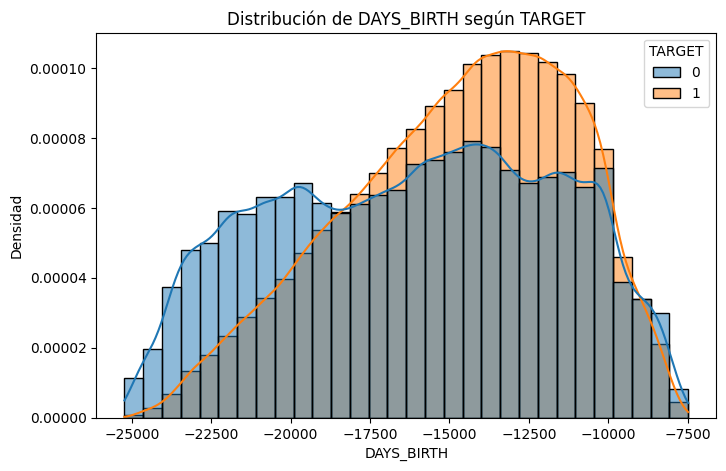

In [262]:
#Histogramas de los mejores atributos por estado de TARGET
for atributo in mejores_atributos:

    plt.figure(figsize=(8,5))

    sns.histplot(
        data=df_balanceado,
        x=atributo,
        hue='TARGET',
        bins=30,
        kde=True,
        stat='density',
        common_norm=False
    )

    plt.title(f'Distribución de {atributo} según TARGET')
    plt.xlabel(atributo)
    plt.ylabel('Densidad')

    plt.show()

En el caso de EXT_SOURCE_2 y EXT_SOURCE_3, se observa que los clientes con TARGET = 1 tienden a concentrarse en valores más bajos respecto a los clientes con TARGET = 0. Esto indica que puntajes externos bajos están asociados a una mayor probabilidad de incumplimiento, mientras que valores altos se relacionan con clientes de menor riesgo crediticio. Además, la separación observable entre ambas distribuciones confirma que estos atributos poseen una alta capacidad predictiva.

Por otro lado, el atributo DAYS_BIRTH también presenta diferencias entre clases. Se aprecia que ciertos rangos de edad muestran una mayor concentración de clientes con incumplimiento, lo que sugiere que la edad influye en el comportamiento de pago de los solicitantes.

In [263]:
#Conclusión automática del ranking
print("Conclusión del ranking predictivo")
print("--------------------------------")

for i, atributo in enumerate(mejores_atributos, start=1):

    fila = ranking_final[ranking_final['Atributo'] == atributo].iloc[0]

    print(f"{i}. {atributo}")
    print(f"   Correlación absoluta: {fila['Correlacion_Absoluta']:.4f}")
    print(f"   Mutual Information: {fila['Mutual_Information']:.4f}")
    print(f"   Diferencia tasa default: {fila['Diferencia_Tasa_Default']:.4f}")
    print(f"   Puntaje final: {fila['Puntaje_Final']:.4f}")
    print()

Conclusión del ranking predictivo
--------------------------------
1. EXT_SOURCE_3
   Correlación absoluta: 0.2929
   Mutual Information: 0.4958
   Diferencia tasa default: 0.4200
   Puntaje final: 0.8737

2. EXT_SOURCE_2
   Correlación absoluta: 0.2959
   Mutual Information: 0.1294
   Diferencia tasa default: 0.4379
   Puntaje final: 0.6479

3. DAYS_BIRTH
   Correlación absoluta: 0.1707
   Mutual Information: 0.4244
   Diferencia tasa default: 0.2859
   Puntaje final: 0.6190



El ranking predictivo permitió identificar los atributos con mayor capacidad para explicar el incumplimiento crediticio dentro del dataset. Para ello se combinaron tres indicadores distintos: correlación absoluta, Mutual Information y diferencia de tasas de default, obteniendo así una evaluación más completa del comportamiento de cada variable respecto al TARGET.

El atributo con mejor desempeño fue EXT_SOURCE_3, el cual obtuvo el mayor puntaje final. Esto indica que la información proveniente de fuentes externas de evaluación crediticia tiene una relación importante con el riesgo de incumplimiento. Además, este atributo mostró simultáneamente altos valores de correlación, Mutual Information y diferencia de tasas de default, evidenciando una fuerte capacidad de separación entre clases.

De manera similar, EXT_SOURCE_2 también presentó una alta calidad predictiva, reforzando la idea de que los scores externos son variables altamente relevantes en la evaluación de riesgo financiero.

Por otro lado, DAYS_BIRTH apareció como uno de los atributos más importantes, lo cual sugiere que la edad del solicitante influye en el comportamiento de pago y en la probabilidad de incumplimiento del crédito.